## Transfer Learning VGG 16 using Keras

In [63]:
!nvidia-smi

Fri May  2 07:26:10 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   64C    P0             29W /   70W |     358MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [64]:
import tensorflow as tf
print(tf.__version__)

2.18.0


In [65]:
# import the libraries as shown below

from tensorflow.keras.layers import Input, Lambda, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
from tensorflow.keras.models import Sequential
import numpy as np
from glob import glob

In [66]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [67]:
ROOT_PATH =' /content/drive/MyDrive/dog -cat' #create dog -cat folder

In [68]:
from google.colab import drive
drive.mount('/content/drive')

# Define the base path for your dataset in Google Drive
base_path = '/content/drive/MyDrive/dog -cat/PetImages'

# Create directories for train and validation if they don't exist
import os
os.makedirs(f'{base_path}/train', exist_ok=True)
os.makedirs(f'{base_path}/validation', exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [70]:
import shutil
import random
import os

# Define paths
src_train = '/kaggle/input/cat-dog-other/cat-dog-other/train'
dst_train = '/content/drive/MyDrive/dog -cat/PetImages/train'
dst_val = '/content/drive/MyDrive/dog -cat/PetImages/validation'

# Create directories for train and validation
os.makedirs(f'{dst_train}', exist_ok=True)
os.makedirs(f'{dst_val}', exist_ok=True)

# Split data
for class_folder in os.listdir(src_train):
    class_path = os.path.join(src_train, class_folder)

    if os.path.isdir(class_path):
        # Create class-based directories in train and validation
        os.makedirs(os.path.join(dst_train, class_folder), exist_ok=True)
        os.makedirs(os.path.join(dst_val, class_folder), exist_ok=True)

        # List all files in the class folder
        files = os.listdir(class_path)

        # Shuffle and split (80% for train, 20% for validation)
        random.shuffle(files)
        split_index = int(0.8 * len(files))

        # Copy the images to train and validation folders
        for file in files[:split_index]:
            shutil.copy(os.path.join(class_path, file), os.path.join(dst_train, class_folder, file))
        for file in files[split_index:]:
            shutil.copy(os.path.join(class_path, file), os.path.join(dst_val, class_folder, file))

print("Data split into train and validation folders.")


Data split into train and validation folders.


In [ ]:
!ls -l /kaggle/input/cat-dog-other/cat-dog-other

In [71]:
!pwd

/content/drive/MyDrive/dog -cat


In [72]:
!ls

PetImages


In [73]:
valid_path = '/content/drive/MyDrive/dog -cat/PetImages/validation'


In [74]:
valid_generator = valid_datagen.flow_from_directory(
    valid_path,
    target_size=IMAGE_SIZE,
    batch_size=32,
    class_mode='categorical'
)


Found 4038 images belonging to 3 classes.


In [75]:
IMAGE_SIZE = [224, 224]

train_path = '/content/drive/MyDrive/dog -cat/PetImages/train'
valid_path = '/content/drive/MyDrive/dog -cat/PetImages/dev'  # optional



In [76]:
# Import the VGG16 library as shown below and add preprocessing layer to the front of VGG
# Here we will be using imagenet weights

vgg16 = VGG16(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)


In [77]:
# don't train existing weights
for layer in vgg16.layers:
  print(layer)

<InputLayer name=input_layer_3, built=True>
<Conv2D name=block1_conv1, built=True>
<Conv2D name=block1_conv2, built=True>
<MaxPooling2D name=block1_pool, built=True>
<Conv2D name=block2_conv1, built=True>
<Conv2D name=block2_conv2, built=True>
<MaxPooling2D name=block2_pool, built=True>
<Conv2D name=block3_conv1, built=True>
<Conv2D name=block3_conv2, built=True>
<Conv2D name=block3_conv3, built=True>
<MaxPooling2D name=block3_pool, built=True>
<Conv2D name=block4_conv1, built=True>
<Conv2D name=block4_conv2, built=True>
<Conv2D name=block4_conv3, built=True>
<MaxPooling2D name=block4_pool, built=True>
<Conv2D name=block5_conv1, built=True>
<Conv2D name=block5_conv2, built=True>
<Conv2D name=block5_conv3, built=True>
<MaxPooling2D name=block5_pool, built=True>


In [78]:
# don't train existing weights
for layer in vgg16.layers:
    layer.trainable = False

In [79]:
for layer in vgg16.layers:
  print(layer.name,layer.trainable)

input_layer_3 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 False
block5_conv2 False
block5_conv3 False
block5_pool False


In [80]:
vgg16.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [81]:
  # useful for getting number of output classes
folders = glob('PetImages/train/*')

In [82]:
folders

['PetImages/train/other', 'PetImages/train/dog', 'PetImages/train/cat']

In [83]:
len(folders)

3

In [92]:
model = Sequential()

model.add(vgg16)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(3,activation='softmax'))

In [93]:
# view the structure of the model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,243 (80.64 MB)

 Trainable params: 6,423,555 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [94]:
# tell the model what cost and optimization method to use
model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)


In [95]:
# Use the Image Data Generator to import the images from the dataset
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1./255)

In [96]:
!pwd

/content/drive/MyDrive/dog -cat


In [97]:
# Make sure you provide the same target size as initialied for the image size
training_set = train_datagen.flow_from_directory('PetImages/train',
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 class_mode = 'categorical')

Found 10735 images belonging to 3 classes.


In [98]:
test_set = test_datagen.flow_from_directory('PetImages/validation',
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'categorical')

Found 4038 images belonging to 3 classes.


In [100]:
# fit the model
# Run the cell. It will take some time to execute
r = model.fit(
  training_set,
  validation_data=test_set,
  epochs=1, #take some more epoch
  steps_per_epoch=len(training_set),
  validation_steps=len(test_set)
)

336/336 ━━━━━━━━━━━━━━━━━━━━ 222s 660ms/step - accuracy: 0.8297 - loss: 0.4544 - val_accuracy: 0.8841 - val_loss: 0.3216


In [101]:
import matplotlib.pyplot as plt

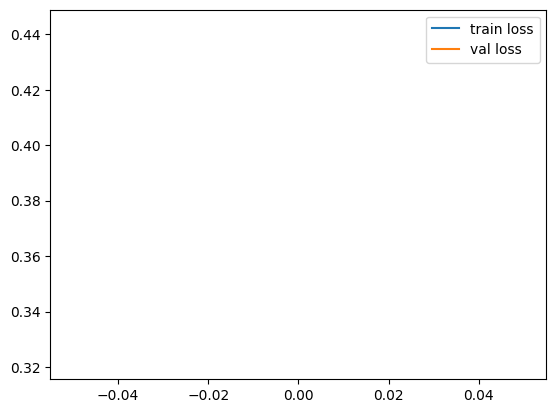

<Figure size 640x480 with 0 Axes>

In [102]:
# plot the loss
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

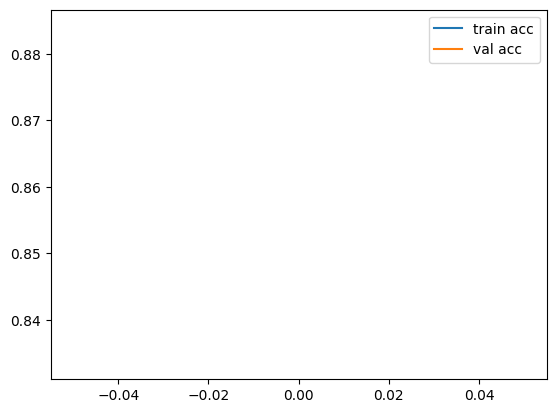

<Figure size 640x480 with 0 Axes>

In [103]:
# plot the accuracy
plt.plot(r.history['accuracy'], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')

In [104]:
# save it as a h5 file
from tensorflow.keras.models import load_model

model.save('model_vgg16.h5')

In [105]:
y_pred = model.predict(test_set)

127/127 ━━━━━━━━━━━━━━━━━━━━ 25s 189ms/step


In [106]:
y_pred

array([[9.1228360e-01, 3.6122672e-02, 5.1593840e-02],
       [9.9460888e-01, 3.9059957e-03, 1.4851312e-03],
       [2.1434484e-04, 9.9661177e-01, 3.1738307e-03],
       ...,
       [6.2980740e-03, 4.6495278e-03, 9.8905236e-01],
       [1.6456340e-02, 1.5408181e-02, 9.6813542e-01],
       [1.3697816e-01, 1.4532496e-01, 7.1769685e-01]], dtype=float32)

In [107]:
import numpy as np
y_pred = np.argmax(y_pred, axis=1)

In [108]:
y_pred

array([0, 0, 1, ..., 2, 2, 2])

In [109]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

In [110]:
model=load_model('model_vgg16.h5')

In [124]:
from google.colab import files
uploaded = files.upload()


Saving hussein-lazim-luvo13Yxjwc-unsplash.jpg to hussein-lazim-luvo13Yxjwc-unsplash.jpg


In [126]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Load the image and resize to match model input
img_path = 'hussein-lazim-luvo13Yxjwc-unsplash.jpg'
img = image.load_img(img_path, target_size=(224, 224))

# Convert image to array and preprocess
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # normalize
img_array = np.expand_dims(img_array, axis=0)  # shape becomes (1, 224, 224, 3)

# Predict
prediction = model.predict(img_array)

# Map prediction to class
class_indices = training_set.class_indices  # e.g., {'Cat': 0, 'Dog': 1, 'Other': 2}
classes = list(class_indices.keys())

predicted_class = classes[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print(f"Predicted class: {predicted_class} ({confidence:.2f}% confidence)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted class: cat (99.88% confidence)


In [127]:
x=image.img_to_array(img)
x

array([[[33., 34., 38.],
        [19., 20., 24.],
        [28., 29., 33.],
        ...,
        [36., 37., 39.],
        [32., 33., 35.],
        [41., 42., 44.]],

       [[34., 35., 39.],
        [24., 25., 29.],
        [28., 29., 33.],
        ...,
        [35., 36., 38.],
        [35., 36., 38.],
        [32., 33., 35.]],

       [[37., 41., 44.],
        [23., 27., 30.],
        [30., 34., 37.],
        ...,
        [28., 29., 31.],
        [27., 28., 30.],
        [35., 36., 38.]],

       ...,

       [[ 9.,  9.,  9.],
        [ 6.,  6.,  6.],
        [11., 11., 11.],
        ...,
        [15., 16., 18.],
        [24., 25., 27.],
        [18., 19., 21.]],

       [[11., 11., 11.],
        [ 5.,  5.,  5.],
        [11., 11., 11.],
        ...,
        [ 9., 10., 12.],
        [17., 18., 20.],
        [14., 15., 17.]],

       [[11., 11., 11.],
        [ 5.,  5.,  5.],
        [ 9.,  9.,  9.],
        ...,
        [12., 13., 15.],
        [15., 16., 18.],
        [11., 12., 14.]]

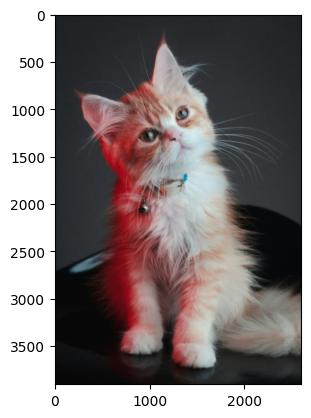

In [129]:
Z = plt.imread('hussein-lazim-luvo13Yxjwc-unsplash.jpg')
plt.imshow(Z)

In [130]:
x.shape

(224, 224, 3)

In [131]:
x=x/255

In [132]:
from keras.applications.vgg16 import preprocess_input

In [133]:
import numpy as np
x=np.expand_dims(x,axis=0)
img_data=preprocess_input(x)
img_data.shape

(1, 224, 224, 3)

In [134]:
model.predict(img_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


array([[0.11234454, 0.07361317, 0.81404227]], dtype=float32)

In [135]:
result = np.argmax(model.predict(img_data), axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [136]:
result[0]

np.int64(2)

In [137]:
if result[0] == 1:
    prediction = 'dog'
    print(prediction)
else:
    prediction = 'cat'
    print(prediction)

cat
